In [1]:
# pip install --upgrade yfinance

In [10]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import pandas_datareader as data

In [11]:
# start = '2015-01-01'
# end = '2024-12-31'
# # df = Data.DataReader('AAPL', 'yahoo',start,end)

In [19]:
# import yfinance as yf
# import pandas as pd

# # Define date range
# start = '2015-01-01'
# end = '2024-12-31'

# # Download AAPL data
# df = yf.download('AAPL', start=start, end=end)

# # Display the first few rows
# print(df.head())

In [109]:
ticker_obj = yf.Ticker('AAPL')
df = ticker_obj.history(start='2010-01-01', end='2019-12-31')

df.head(3)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-01-04 00:00:00-05:00,6.422875,6.455075,6.391277,6.440330,493729600,0.0,0.0
2010-01-05 00:00:00-05:00,6.458087,6.487879,6.417460,6.451466,601904800,0.0,0.0
2010-01-06 00:00:00-05:00,6.451466,6.477046,6.342226,6.348847,552160000,0.0,0.0


In [34]:
df.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-12-23 00:00:00-05:00,67.917550,68.818178,67.878812,68.757652,98572000,0.0,0.0
2019-12-24 00:00:00-05:00,68.924716,68.973140,68.496193,68.823029,48478800,0.0,0.0
2019-12-26 00:00:00-05:00,68.956196,70.205456,68.927145,70.188507,93121200,0.0,0.0
2019-12-27 00:00:00-05:00,70.481460,71.171459,69.755147,70.161880,146266000,0.0,0.0
2019-12-30 00:00:00-05:00,70.079551,70.861551,69.053030,70.578285,144114400,0.0,0.0


In [38]:
# df = df.drop(df['Date'], axis =1)
df = df.reset_index()
df.head()

,index,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,0,2010-01-04 00:00:00-05:00,6.422875,6.455075,6.391277,6.440330,493729600,0.0,0.0
1,1,2010-01-05 00:00:00-05:00,6.458087,6.487879,6.417460,6.451466,601904800,0.0,0.0
2,2,2010-01-06 00:00:00-05:00,6.451466,6.477046,6.342226,6.348847,552160000,0.0,0.0
3,3,2010-01-07 00:00:00-05:00,6.372320,6.379844,6.291067,6.337110,477131200,0.0,0.0
4,4,2010-01-08 00:00:00-05:00,6.328684,6.379844,6.291369,6.379241,447610800,0.0,0.0


In [42]:
# df = df.drop(['index'], axis=1)
df = df.drop(['Date','Dividends','Stock Splits'], axis=1)
df.head()

,Open,High,Low,Close,Volume
0,6.422875,6.455075,6.391277,6.440330,493729600
1,6.458087,6.487879,6.417460,6.451466,601904800
2,6.451466,6.477046,6.342226,6.348847,552160000
3,6.372320,6.379844,6.291067,6.337110,477131200
4,6.328684,6.379844,6.291369,6.379241,447610800


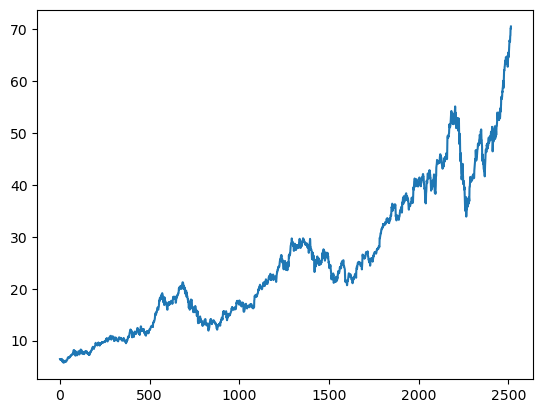

In [43]:
plt.plot(df.Close)

In [44]:
ma100 = df.Close.rolling(100).mean()
ma100

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
2510    57.212838
2511    57.410469
2512    57.647437
2513    57.875338
2514    58.102497
Name: Close, Length: 2515, dtype: float64

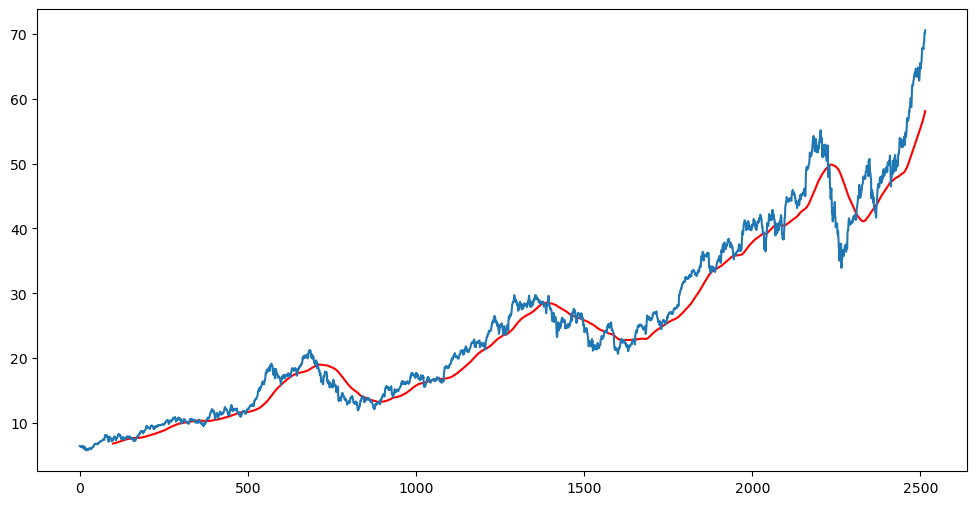

In [45]:
plt.figure(figsize=(12,6))
plt.plot(ma100, 'r')
plt.plot(df.Close)

In [46]:
ma200 = df.Close.rolling(200).mean()

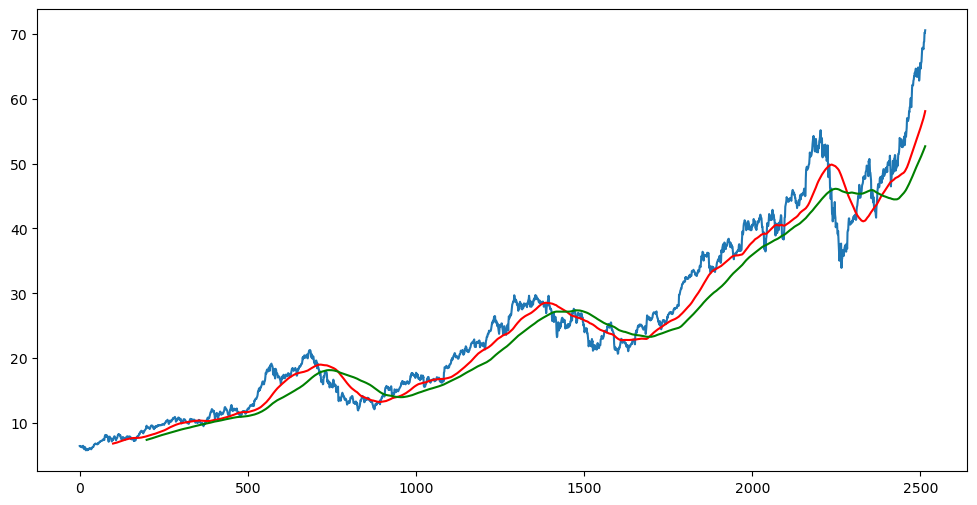

In [47]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200 , 'g')

In [48]:
df.shape

(2515, 5)

In [49]:
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.7):len(df)])

In [51]:

print(data_training.head())
print(data_testing.head())

      Close
0  6.440330
1  6.451466
2  6.348847
3  6.337110
4  6.379241
          Close
1760  26.996561
1761  26.786110
1762  26.862425
1763  26.832359
1764  26.968815


In [52]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range= (0,1))

In [53]:
data_training_array = scaler.fit_transform(data_training)

In [54]:
data_training_array

array([[0.02759996],
       [0.02806507],
       [0.02377927],
       ...,
       [0.8840842 ],
       [0.89123165],
       [0.88640219]])

In [51]:
data_training_array.shape

(1760, 1)

In [55]:
x_train = []
y_train= []

for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100 : i])
    y_train.append(data_training_array[i,0])

In [56]:
x_train,y_train = np.array(x_train), np.array(y_train)

In [57]:
x_train.shape

(1660, 100, 1)

In [86]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [87]:
model = Sequential()
model.add(LSTM(units= 50, activation= 'relu',return_sequences=True, 
              input_shape = (x_train.shape[1],1)))
model. add (Dropout (0.2))

model.add(LSTM(units= 60, activation= 'relu',return_sequences=True))
model. add (Dropout (0.3))


model.add(LSTM(units= 60, activation= 'relu',return_sequences=True))
model. add (Dropout (0.4))

model.add(LSTM(units= 120, activation= 'relu'))
model. add (Dropout (0.5))

model.add(Dense(units =1))

/Users/yashshah/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [88]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 60)        │        29,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 120)            │        86,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,081 (597.97 KB)

 Trainable params: 153,081 (597.97 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.1406
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.0173
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0114
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0104
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0095
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0090
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.0089
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0083
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0087
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0082
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.0078
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0085
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0063
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.0060
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.006

In [90]:
model.save('keras_model.h5')

In [91]:
data_testing.head()

,Close
1760,26.996561
1761,26.786110
1762,26.862425
1763,26.832359
1764,26.968815


In [92]:
data_training.tail()

,Close
1755,27.072889
1756,26.894810
1757,26.948002
1758,27.119141
1759,27.003504


In [ ]:
past_100_days = data_training.tail(100)

In [ ]:
final_df = past_100_days.append(data_testing,ignore_index = True)

/var/folders/g8/kpw7958101scbg6jc_dw_ggr0000gn/T/ipykernel_46469/2767363129.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final_df = past_100_days.append(data_testing,ignore_index = True)


In [ ]:
final_df.head()

,Close
0,27.072889
1,26.894810
2,26.948002
3,27.119141
4,27.003504


In [96]:
input_data = scaler.fit_transform(final_df)

In [97]:
input_data
input_data.shape

(760, 1)

In [ ]:
x_test = [] 
y_test = []

for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100 : i])
    y_test.append(input_data[i,0])

In [99]:
x_test,y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(660, 100, 1)
(660,)


In [100]:
y_predicted = model.predict(x_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


In [ ]:
y_predicted.shape

(660, 1)

In [102]:
y_test 

array([0.18855986, 0.20075653, 0.20352572, 0.20847901, 0.20746715,
       0.20501729, 0.20783998, 0.20645546, 0.20677472, 0.20192797,
       0.20416502, 0.21625472, 0.20815949, 0.21092904, 0.21582875,
       0.21380503, 0.1817961 , 0.16283549, 0.16906702, 0.16145098,
       0.15681739, 0.14605889, 0.16773529, 0.16065202, 0.1652323 ,
       0.16395397, 0.16741586, 0.16496592, 0.15383468, 0.16501897,
       0.15356856, 0.15537939, 0.15260993, 0.15575213, 0.14850883,
       0.15623158, 0.16091822, 0.16342139, 0.16453996, 0.17535185,
       0.18211587, 0.18488498, 0.18765471, 0.19266104, 0.18903965,
       0.18866648, 0.19835954, 0.20182161, 0.20565633, 0.19021118,
       0.18456547, 0.18046455, 0.18749477, 0.22525605, 0.21689436,
       0.22126122, 0.23415006, 0.24091426, 0.24613366, 0.21881119,
       0.23036047, 0.24303214, 0.25238949, 0.24891392, 0.23239194,
       0.230467  , 0.22891663, 0.24265818, 0.24372727, 0.23993106,
       0.24308571, 0.25169427, 0.25939402, 0.26174666, 0.26522

In [103]:
y_predicted

array([[0.23334172],
       [0.23661524],
       [0.23978537],
       [0.24272916],
       [0.24537519],
       [0.24768442],
       [0.24963912],
       [0.2512498 ],
       [0.25254196],
       [0.25355256],
       [0.25431126],
       [0.25485343],
       [0.255254  ],
       [0.25556743],
       [0.25584075],
       [0.256124  ],
       [0.25644985],
       [0.25675797],
       [0.25694284],
       [0.2569108 ],
       [0.25657684],
       [0.2558857 ],
       [0.2548048 ],
       [0.25336486],
       [0.2516227 ],
       [0.2496559 ],
       [0.24754657],
       [0.24538118],
       [0.24323384],
       [0.2411417 ],
       [0.23915243],
       [0.23727944],
       [0.2355318 ],
       [0.23390797],
       [0.2324082 ],
       [0.23101424],
       [0.22972846],
       [0.2285758 ],
       [0.22759101],
       [0.22680509],
       [0.22627306],
       [0.22605689],
       [0.22620016],
       [0.22671925],
       [0.2276111 ],
       [0.2288157 ],
       [0.23025471],
       [0.231

In [104]:
scaler.scale_

array([0.02283513])

In [105]:
scale_factor = 1/0.02283513
y_predicted = y_predicted * scale_factor
y_test = y_test * scale_factor

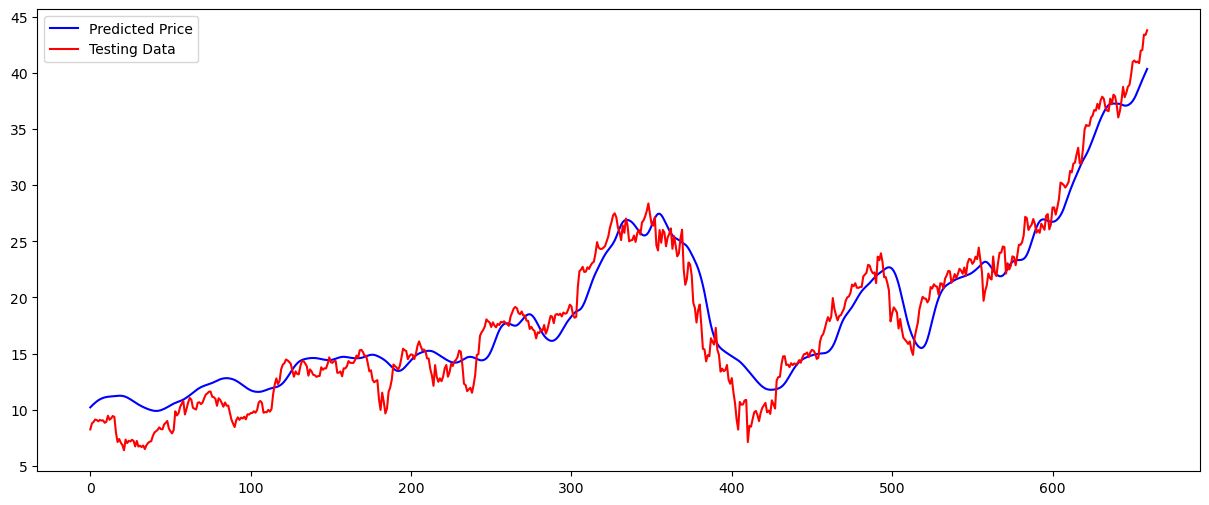

In [108]:
plt.figure(figsize=(15,6))
plt.plot(y_predicted,'b',label = 'Predicted Price')
plt.plot(y_test,'r',label = 'Testing Data')
plt.legend()
plt.show()